# Predictive Maintenance using NASA CMAPSS Dataset

## Problem Statement
Unexpected equipment failures can cause downtime, increased maintenance costs, and reduced operational efficiency. Traditional maintenance approaches often fail to prevent these issues because they either react after a failure occurs or follow fixed maintenance schedules.Aircraft engines generate large volumes of sensor data during operation. Predicting engine degradation before failure is critical for ensuring safety, reducing maintenance costs, and minimizing operational disruptions.

### Objective
The goal of this project is to predict the **Remaining Useful Life (RUL)** of an engine using sensor data from the **NASA CMAPSS Turbofan Engine Dataset**.

### Why It Matters
 Accurate RUL prediction enables: - Proactive maintenance planning - Reduced equipment downtime - Lower maintenance costs - Improved operational reliability - Better resource utilization

### Proposed Solution
This project applies **Machine Learning** techniques to analyze engine sensor data and estimate the remaining operational cycles before failure. By predicting RUL, maintenance activities can be scheduled at the right time, minimizing unexpected breakdowns and improving overall system performance.

## Import Libraries



In [1]:
import pandas as pd
import numpy as np

## Load Dataset

In [2]:
columns = ['engine_id', 'cycle']

for i in range(1, 4):
    columns.append(f'operational_setting_{i}')

for i in range(1, 22):
    columns.append(f'sensor_{i}')

df = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)
df.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Dataset Overview

In [3]:
print("Shape:", df.shape)

Shape: (20631, 26)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   engine_id              20631 non-null  int64  
 1   cycle                  20631 non-null  int64  
 2   operational_setting_1  20631 non-null  float64
 3   operational_setting_2  20631 non-null  float64
 4   operational_setting_3  20631 non-null  float64
 5   sensor_1               20631 non-null  float64
 6   sensor_2               20631 non-null  float64
 7   sensor_3               20631 non-null  float64
 8   sensor_4               20631 non-null  float64
 9   sensor_5               20631 non-null  float64
 10  sensor_6               20631 non-null  float64
 11  sensor_7               20631 non-null  float64
 12  sensor_8               20631 non-null  float64
 13  sensor_9               20631 non-null  float64
 14  sensor_10              20631 non-null  float64
 15  se

In [5]:
df.describe()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


## Create Remaining Useful Life (RUL)

In [6]:
max_cycle = df.groupby('engine_id')['cycle'].max().reset_index()

max_cycle.columns = ['engine_id', 'max_cycle']

df = df.merge(max_cycle, on='engine_id')

df['RUL'] = df['max_cycle'] - df['cycle']

df.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187


In [7]:
print("Number of Engines:", df['engine_id'].nunique())

Number of Engines: 100


In [8]:
df.groupby('engine_id')['cycle'].max().head()

,cycle
engine_id,
1,192
2,287
3,179
4,189
5,269


In [9]:
df['RUL'].describe()

,RUL
count,20631.000000
mean,107.807862
std,68.880990
min,0.000000
25%,51.000000
50%,103.000000
75%,155.000000
max,361.000000


## Data Quality Analysis

In [10]:
df.isnull().sum()

,0
engine_id,0
cycle,0
operational_setting_1,0
operational_setting_2,0
operational_setting_3,0
sensor_1,0
sensor_2,0
sensor_3,0
sensor_4,0
sensor_5,0


In [11]:
variance = df.var(numeric_only=True)

variance.sort_values()

,0
operational_setting_3,0.000000e+00
sensor_18,0.000000e+00
sensor_19,0.000000e+00
sensor_16,2.422479e-28
sensor_10,2.172333e-25
sensor_5,1.152399e-23
sensor_1,4.273435e-21
operational_setting_2,8.588541e-08
sensor_6,1.929279e-06
operational_setting_1,4.784340e-06


In [12]:
constant_cols = []

for col in df.columns:
    if df[col].nunique() == 1:
        constant_cols.append(col)

print("Constant Columns:")
print(constant_cols)

Constant Columns:
['operational_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


In [13]:
corr = df.corr(numeric_only=True)

rul_corr = corr["RUL"].sort_values(ascending=False)

rul_corr

,RUL
RUL,1.000000
sensor_12,0.671983
sensor_7,0.657223
sensor_21,0.635662
sensor_20,0.629428
max_cycle,0.363152
engine_id,0.078753
operational_setting_2,-0.001948
operational_setting_1,-0.003198
sensor_6,-0.128348


## Exploratory Data Analysis

### Univariate Analysis

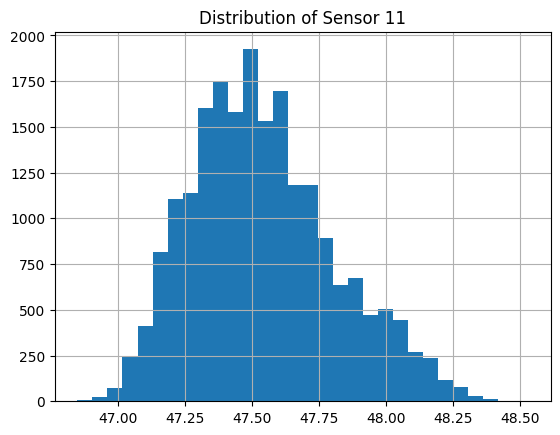

In [14]:
import matplotlib.pyplot as plt

df['sensor_11'].hist(bins=30)

plt.title("Distribution of Sensor 11")

plt.show()

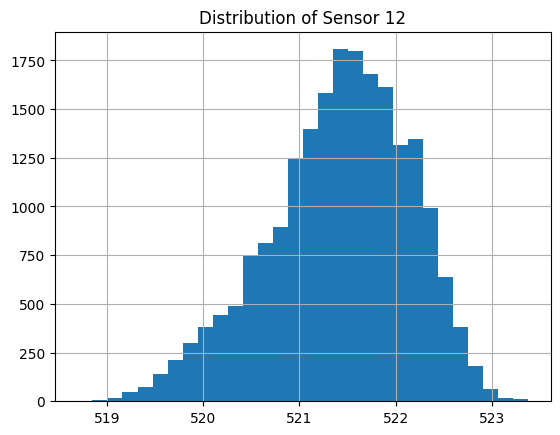

In [15]:
df['sensor_12'].hist(bins=30)

plt.title("Distribution of Sensor 12")

plt.show()

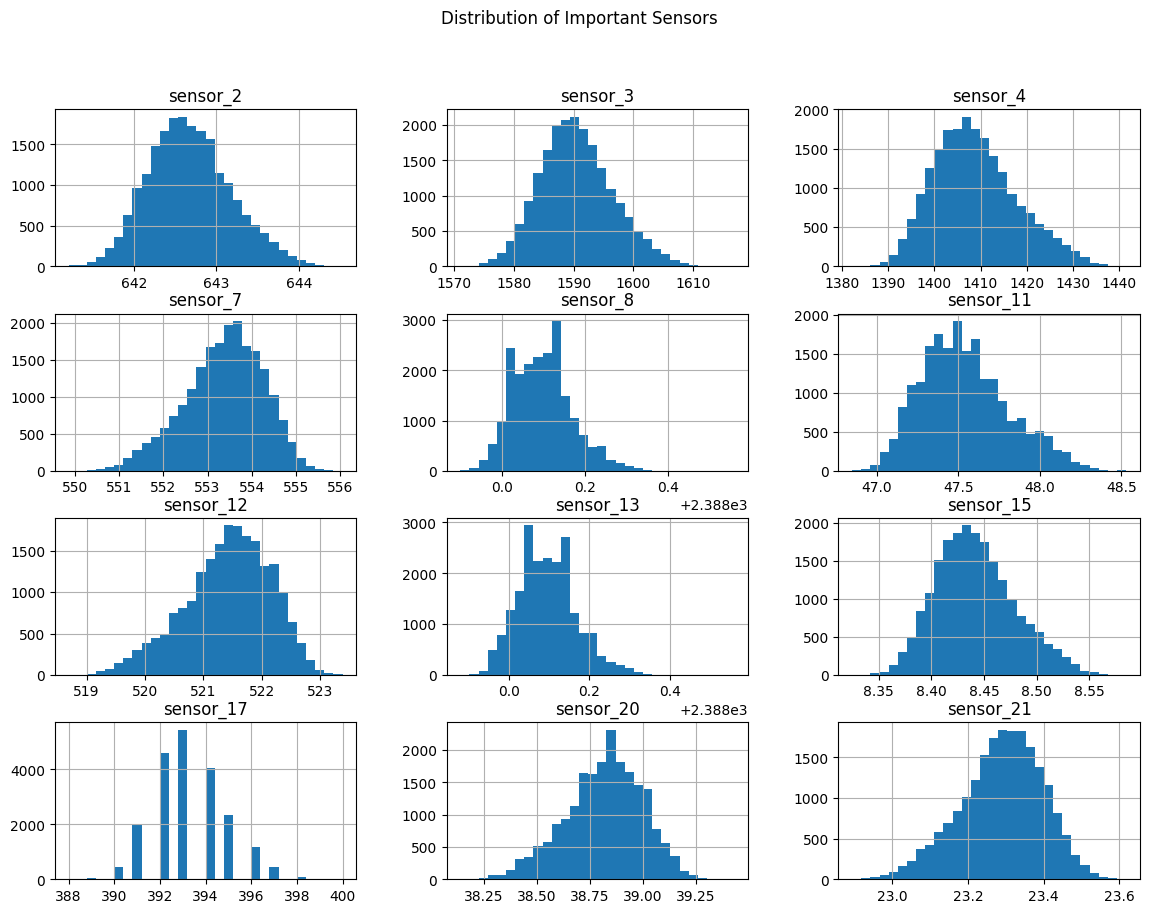

In [16]:
important_sensors = [
    'sensor_2',
    'sensor_3',
    'sensor_4',
    'sensor_7',
    'sensor_8',
    'sensor_11',
    'sensor_12',
    'sensor_13',
    'sensor_15',
    'sensor_17',
    'sensor_20',
    'sensor_21'
]

df[important_sensors].hist(
    figsize=(14,10),
    bins=30
)

plt.suptitle("Distribution of Important Sensors")

plt.show()

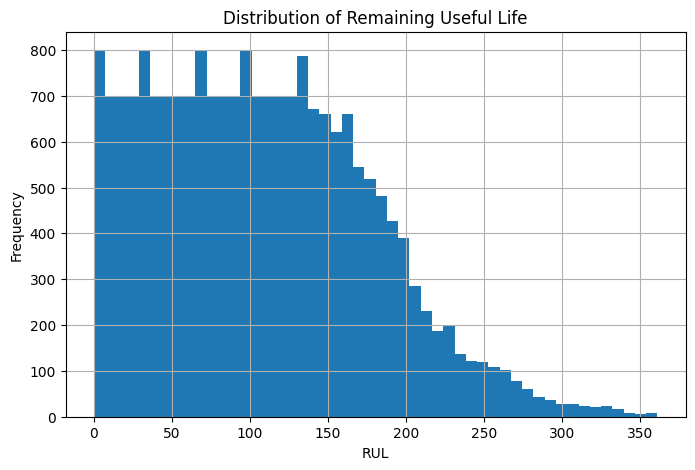

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df['RUL'].hist(bins=50)

plt.title("Distribution of Remaining Useful Life")

plt.xlabel("RUL")

plt.ylabel("Frequency")

plt.show()

In [18]:
Q1 = df['RUL'].quantile(0.25)
Q3 = df['RUL'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['RUL'] < lower) | (df['RUL'] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 104


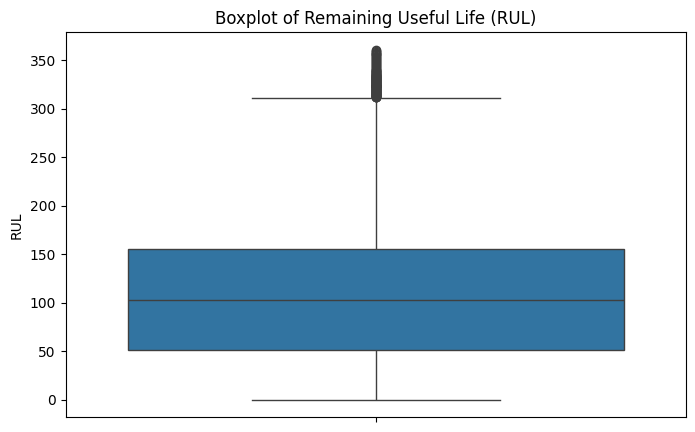

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(y=df['RUL'])

plt.title('Boxplot of Remaining Useful Life (RUL)')
plt.ylabel('RUL')

plt.show()

### Bivariate Analysis

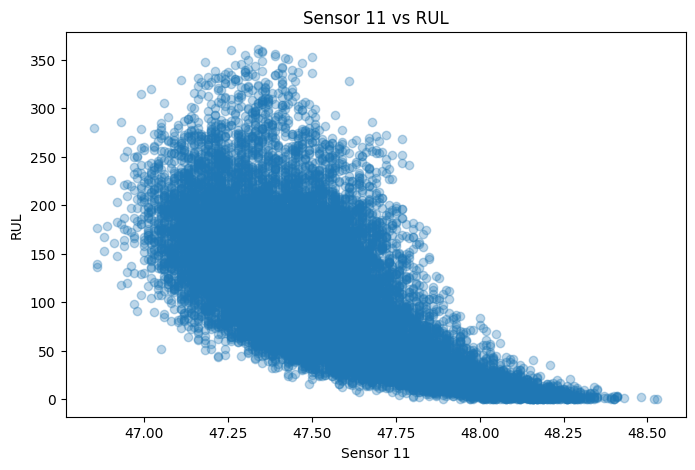

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['sensor_11'],
    df['RUL'],
    alpha=0.3
)

plt.xlabel("Sensor 11")
plt.ylabel("RUL")

plt.title("Sensor 11 vs RUL")

plt.show()

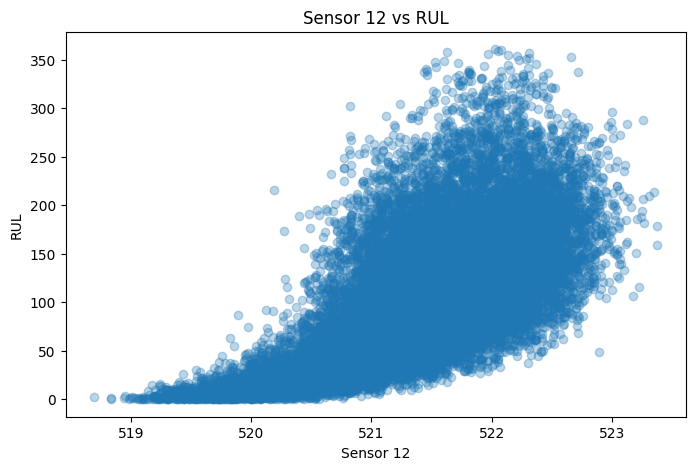

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['sensor_12'],
    df['RUL'],
    alpha=0.3
)

plt.xlabel("Sensor 12")
plt.ylabel("RUL")

plt.title("Sensor 12 vs RUL")

plt.show()

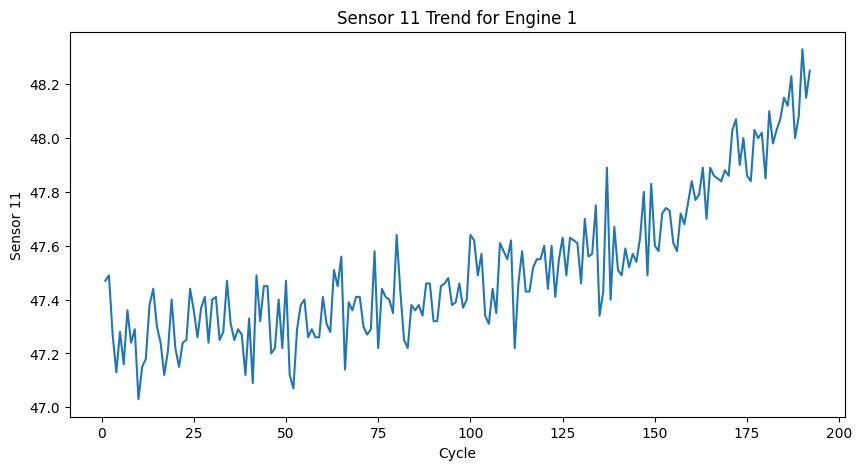

In [21]:
engine_1 = df[df['engine_id'] == 1]

plt.figure(figsize=(10,5))

plt.plot(
    engine_1['cycle'],
    engine_1['sensor_11']
)

plt.xlabel("Cycle")
plt.ylabel("Sensor 11")

plt.title("Sensor 11 Trend for Engine 1")

plt.show()

### Multivariate Analysis

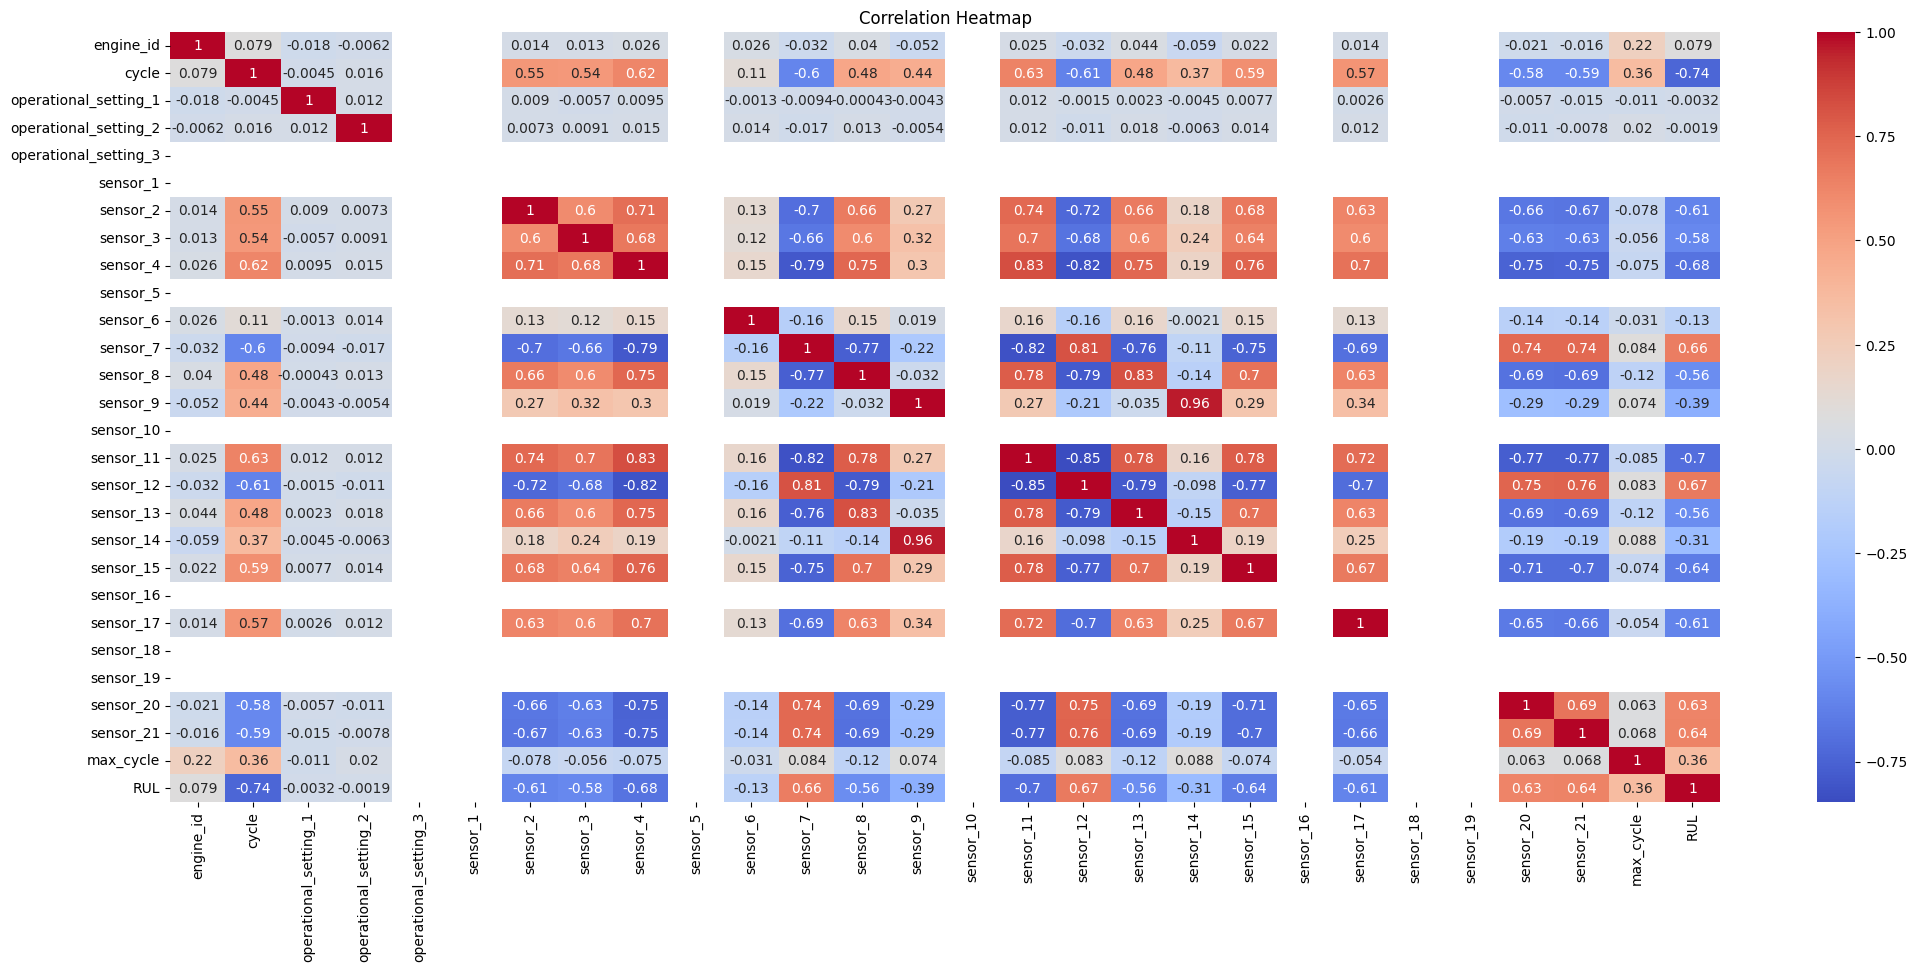

In [22]:
import seaborn as sns

plt.figure(figsize=(25,10))

sns.heatmap(
    df.corr(numeric_only=True),annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

## EDA Summary

### Key Findings

1. No missing values were found.

2. Constant sensors identified:
   - operational_setting_3
   - sensor_1
   - sensor_5
   - sensor_10
   - sensor_16
   - sensor_18
   - sensor_19

3. Strong positive correlation with RUL:
   - sensor_12
   - sensor_7
   - sensor_21
   - sensor_20

4. Strong negative correlation with RUL:
   - sensor_11
   - sensor_4
   - sensor_15
   - sensor_2

5. Constant sensors will be removed before model training.

## Remove Constant Sensors

In [23]:
constant_cols = [
    'operational_setting_3',
    'sensor_1',
    'sensor_5',
    'sensor_6',
    'sensor_10',
    'sensor_16',
    'sensor_18',
    'sensor_19'
]

In [24]:
df_clean = df.drop(columns=constant_cols)

print(df_clean.shape)

(20631, 20)


## Feature Selection

In [25]:
selected_features = [
    'cycle',
    'sensor_2',
    'sensor_3',
    'sensor_4',
    'sensor_7',
    'sensor_8',
    'sensor_11',
    'sensor_12',
    'sensor_13',
    'sensor_15',
    'sensor_17',
    'sensor_20',
    'sensor_21'
]

In [26]:
print("Selected Features:")
for feature in selected_features:
    print(feature)

Selected Features:
cycle
sensor_2
sensor_3
sensor_4
sensor_7
sensor_8
sensor_11
sensor_12
sensor_13
sensor_15
sensor_17
sensor_20
sensor_21


In [27]:
X = df_clean[selected_features]

y = df_clean['RUL']

In [28]:
print(X.shape)

(20631, 13)


## Feature Scaling

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [30]:
X_scaled[:5]

array([[0.        , 0.18373494, 0.40680183, 0.30975692, 0.72624799,
        0.24242424, 0.36904762, 0.63326226, 0.20588235, 0.36398615,
        0.33333333, 0.71317829, 0.7246617 ],
       [0.00277008, 0.28313253, 0.4530194 , 0.35263336, 0.62801932,
        0.21212121, 0.38095238, 0.76545842, 0.27941176, 0.41131204,
        0.33333333, 0.66666667, 0.73101353],
       [0.00554017, 0.34337349, 0.36952256, 0.37052667, 0.71014493,
        0.27272727, 0.25      , 0.79530917, 0.22058824, 0.35744517,
        0.16666667, 0.62790698, 0.62137531],
       [0.00831025, 0.34337349, 0.25615871, 0.33119514, 0.74074074,
        0.31818182, 0.16666667, 0.8891258 , 0.29411765, 0.16660254,
        0.33333333, 0.57364341, 0.66238608],
       [0.01108033, 0.34939759, 0.25746675, 0.40462525, 0.66827697,
        0.24242424, 0.25595238, 0.74626866, 0.23529412, 0.40207772,
        0.41666667, 0.58914729, 0.70450152]])

In [31]:
print(X_scaled.min())
print(X_scaled.max())

0.0
1.0


## Train Test Split

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (16504, 13)
Testing Set Shape: (4127, 13)


## Data Preprocessing Summary

### Completed Tasks

- Removed constant sensors.
- Selected important sensor features.
- Applied MinMax normalization.
- Split data into training and testing datasets.

### Result

The dataset is now ready for machine learning model training.

# Model Building

## Random Forest Regressor

In [34]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [35]:
rf_predictions = rf_model.predict(X_test)

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_mse = mean_squared_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
---------------------
MAE : 26.956942088684276
RMSE: 37.36875972639736
R²  : 0.694356134301559


## XGBoost Regressor

In [37]:
!pip install xgboost

In [53]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [54]:
xgb_predictions = xgb_model.predict(X_test)

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_mse = mean_squared_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(xgb_mse)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("XGBoost Results")
print("----------------")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

XGBoost Results
----------------
MAE : 26.54979705810547
RMSE: 37.03398427405479
R²  : 0.69980788230896


In [56]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        rf_rmse,
        xgb_rmse
    ],
    "R2 Score": [
        rf_r2,
        xgb_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Random Forest,26.956942,37.368760,0.694356
1,XGBoost,26.549797,37.033984,0.699808


In [57]:
best_model = comparison.sort_values(
    by="RMSE"
)

best_model

,Model,MAE,RMSE,R2 Score
1,XGBoost,26.549797,37.033984,0.699808
0,Random Forest,26.956942,37.368760,0.694356


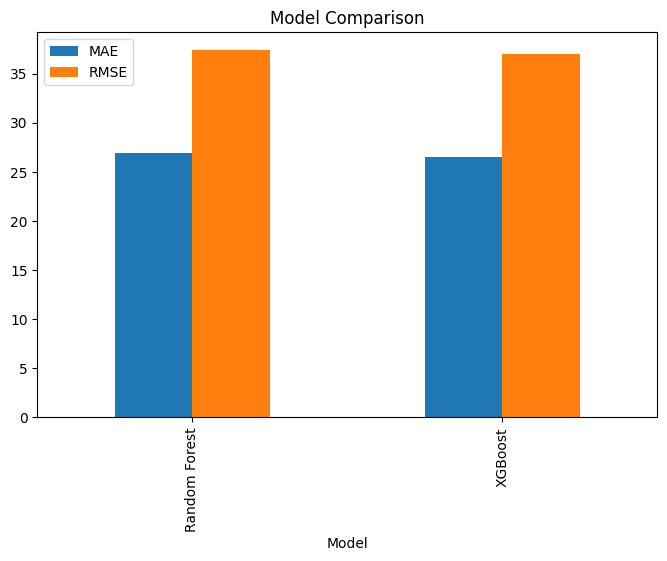

In [58]:
comparison.set_index("Model")[[
    "MAE",
    "RMSE"

]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison")
plt.show()

## Model Comparison Summary

Two machine learning models were trained for Remaining Useful Life (RUL) prediction.

### Random Forest
- MAE: 26.96
- RMSE: 37.37
- R² Score: 0.694

### XGBoost
- MAE: 26.55
- RMSE: 37.03
- R² Score: 0.700

### Best Model

XGBoost achieved the lowest RMSE and highest R² score and was selected as the best-performing model.

In [60]:
import joblib

joblib.dump(
    xgb_model,
    "best_xgboost_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
